# Feature Engineering - Wind-Assisted Propulsion

This notebook prepares the `MasterSet.csv` dataset for machine learning by engineering physically meaningful features from raw AIS and metocean data.

## What we start with (`MasterSet.csv`)
The master dataset is a merged table of:
- **AIS data** - vessel position, speed over ground (SOG), course over ground (COG)
- **ERA5 / Copernicus wind data** - `u10`, `v10` (wind vector components at 10m height)
- **Copernicus wave data** - `H_s` (significant wave height), `mwd`, `mwp`
- **Copernicus ocean currents** - `uo`, `vo` (current vector components)

## What we compute in this notebook
1. **STW** - Speed Through Water: removes the ocean current contribution from SOG to get the vessel's speed relative to the water mass
2. **AWS / AWA** - Apparent Wind Speed and Apparent Wind Angle: the wind as experienced on the moving vessel, accounting for the vessel's own velocity
3. **Rotor Power** - estimated propulsion contribution from the Flettner rotor, looked up from the manufacturer polar diagram
4. **`is_rotor_active`** - binary flag (1 = rotors operating, 0 = rotors off) based on physical boundary conditions

## Output
Enriched CSV saved to `data/MasterSet_features.csv`, ready for model training.

## 0. Setup

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

DATA_PATH = './data/MasterSet.csv'
OUTPUT_PATH = './data/MasterSet_features.csv'

In [6]:
df = pd.read_csv(DATA_PATH, parse_dates=['Time'])

print(f"Shape (raw): {df.shape}")
print("Time range: " + str(df['Time'].min()) + " to " + str(df['Time'].max()))
print("Columns: " + str(df.columns.tolist()))
df.head(3)

Shape (raw): (125160, 18)
Time range: 2023-02-02 00:06:00 to 2026-02-02 07:25:00
Columns: ['Time', 'Lat', 'Lon', 'Speed_kn', 'Calc_Speed_kn', 'Course_deg', 'Dist_since_last_nm', 'Total_dist_nm', 'Voyage_ID', 'u10', 'v10', 'H_s', 'mwd', 'mwp', 'fg10', 'uo', 'vo', 'True_Wind_Speed_ms']


,Time,Lat,Lon,Speed_kn,Calc_Speed_kn,Course_deg,Dist_since_last_nm,Total_dist_nm,Voyage_ID,u10,v10,H_s,mwd,mwp,fg10,uo,vo,True_Wind_Speed_ms
0,2023-02-02 00:06:00,56.826667,-0.128333,15.0,NaN,357.0,0.000000,0.000000,1,6.927567,1.263245,2.486592,329.23230,7.967768,9.910109,0.141454,0.074032,7.041801
1,2023-02-02 00:21:00,56.886667,-0.125000,15.0,14.4,47.0,3.608126,3.608126,1,6.934403,0.725159,2.486592,329.23230,7.967768,10.196241,0.138265,0.034948,6.972216
2,2023-02-02 00:33:00,56.923333,-0.058333,16.0,15.5,46.0,3.105603,6.713728,1,7.726562,0.150864,2.307535,330.84406,7.845758,9.927878,0.150498,0.017536,7.728035


## 1. Speed Through Water (STW)

**Why this matters:** SOG (Speed Over Ground) is the vessel's speed relative to the seabed as measured by GPS. However, ocean currents push or retard the vessel - a 2 m/s current in the direction of travel inflates SOG without the engine doing extra work. For any physics-based analysis, we need **STW (Speed Through Water)**: how fast the hull is actually moving through the water mass. This is what the engine and rotors actually act on.

**Method:**
1. Decompose SOG + COG into east/north velocity components (converting knots → m/s)
2. Subtract the ocean current vector (`uo`, `vo`) to get the ship's velocity through the water
3. Recompose into a scalar speed (STW) and a heading (STH - ship true heading through water)

$$V_{ship,east} = SOG \cdot \sin(COG), \quad V_{ship,north} = SOG \cdot \cos(COG)$$

$$STW_x = V_{ship,east} - u_o, \quad STW_y = V_{ship,north} - v_o$$

$$STW = \sqrt{STW_x^2 + STW_y^2}$$

> **Unit note:** `uo`, `vo` from Copernicus are in m/s. SOG is in knots. We convert SOG to m/s (1 kn = 0.51444 m/s) before the vector subtraction, then convert STW back to knots for interpretability.

In [7]:
KN_TO_MS = 0.51444  # conversion factor: 1 knot = 0.51444 m/s

# Convert COG from degrees to radians for trigonometry
cog_rad = np.deg2rad(df['Course_deg'])

# Decompose SOG (converted to m/s) into east and north components
sog_ms = df['Speed_kn'] * KN_TO_MS
ship_vx = sog_ms * np.sin(cog_rad)  # eastward component [m/s]
ship_vy = sog_ms * np.cos(cog_rad)  # northward component [m/s]

# Subtract ocean current vector to get velocity through water
stw_x = ship_vx - df['uo']  # eastward component of STW [m/s]
stw_y = ship_vy - df['vo']  # northward component of STW [m/s]

# Recompose into scalar speed (m/s) and convert back to knots
df['STW_ms'] = np.sqrt(stw_x ** 2 + stw_y ** 2)  # [m/s]
df['STW_kn'] = df['STW_ms'] / KN_TO_MS  # [knots]

# Ship's true heading through water (degrees from north, clockwise)
df['STH_deg'] = np.rad2deg(np.arctan2(stw_x, stw_y)) % 360

# Store intermediate ship velocity components for later use in AWA calculation
df['_ship_vx'] = ship_vx
df['_ship_vy'] = ship_vy

print("STW statistics [knots]:")
print(df['STW_kn'].describe().round(2))

STW statistics [knots]:
count    125160.00
mean         11.53
std           2.14
min           4.10
25%          10.18
50%          11.67
75%          12.81
max          19.95
Name: STW_kn, dtype: float64


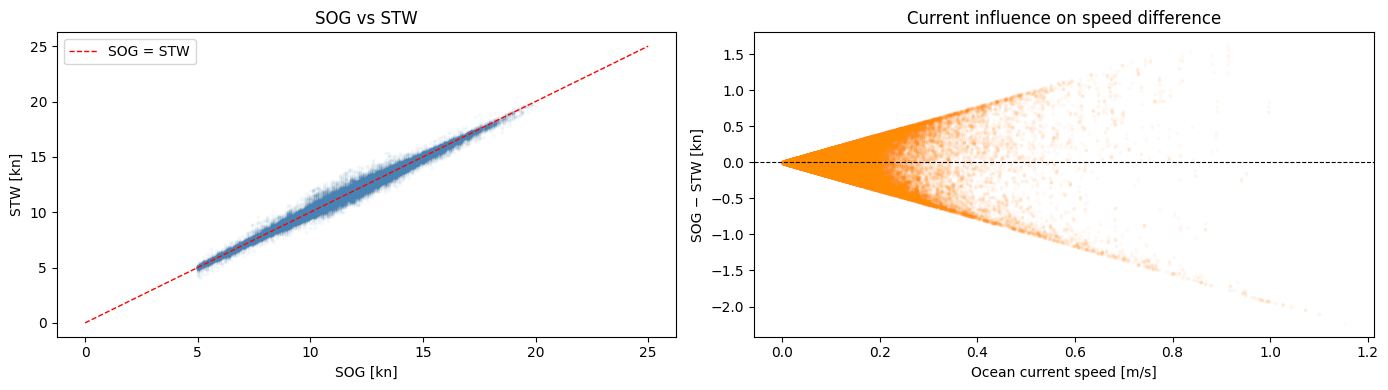

In [8]:
# Sanity check: STW should be close to SOG when currents are weak
# and the difference (SOG - STW) should correlate with current strength
current_speed = np.sqrt(df['uo'] ** 2 + df['vo'] ** 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(df['Speed_kn'], df['STW_kn'], alpha=0.03, s=3, color='steelblue')
axes[0].plot([0, 25], [0, 25], 'r--', linewidth=1, label='SOG = STW')
axes[0].set_xlabel('SOG [kn]')
axes[0].set_ylabel('STW [kn]')
axes[0].set_title('SOG vs STW')
axes[0].legend()

axes[1].scatter(current_speed, df['Speed_kn'] - df['STW_kn'], alpha=0.03, s=3, color='darkorange')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Ocean current speed [m/s]')
axes[1].set_ylabel('SOG − STW [kn]')
axes[1].set_title('Current influence on speed difference')

plt.tight_layout()
plt.show()

## 2. Apparent Wind Speed (AWS) and Apparent Wind Angle (AWA)

**Why this matters:** A vessel moving forward creates its own headwind. The wind a sailor actually feels - the **apparent wind** - is the vector sum of the true wind and the wind created by the vessel's motion. Flettner rotors respond to apparent wind, not true wind. So AWS and AWA are the correct physical inputs to the rotor power model.

**Illustration:** If the true wind is 10 m/s from the west and the ship sails north at ~8 m/s (≈15 kn), the apparent wind is shifted forward from 90° abeam toward ~52° (forward of abeam) due to the ship's headway.

**Method:**

$$\vec{W}_{apparent} = \vec{W}_{true} - \vec{V}_{ship}$$

$$AW_x = u_{10} - V_{ship,east}, \quad AW_y = v_{10} - V_{ship,north}$$

$$AWS = \sqrt{AW_x^2 + AW_y^2}$$

$$AWA = \text{atan2}(-AW_x,\; -AW_y) - COG \quad \text{[normalized to } -180°\text{ to }+180°\text{]}$$

The negation of the vector components converts from the "wind blowing TO" direction to the "wind coming FROM" direction, which is the correct physical definition of AWA.

> **Convention:** AWA = 0° means wind from directly ahead (headwind). AWA = ±90° means wind abeam. AWA = ±180° means wind from directly astern. Negative = port side, positive = starboard side. For the rotor lookup table we use |AWA| since the polar diagram is symmetric.

In [9]:
def normalize_angle(angle_deg):
    return ((angle_deg + 180) % 360) - 180


# Apparent wind vector: true wind minus ship velocity
aw_x = df['u10'] - df['_ship_vx']  # eastward component of apparent wind [m/s]
aw_y = df['v10'] - df['_ship_vy']  # northward component of apparent wind [m/s]

# Apparent Wind Speed [m/s]
df['AWS_ms'] = np.sqrt(aw_x ** 2 + aw_y ** 2)

# Direction the apparent wind is blowing FROM (from north, clockwise) [degrees].
# We negate aw_x and aw_y to flip from the TO direction to the FROM direction.
# AWA is defined as the angle the wind arrives from - not the direction it blows toward.
aw_direction_deg = np.rad2deg(np.arctan2(-aw_x, -aw_y)) % 360

# Apparent Wind Angle relative to ship's bow, normalized to [-180, 180]
# Positive = starboard, Negative = port
df['AWA_deg'] = normalize_angle(aw_direction_deg - df['Course_deg'])

# Absolute AWA [0, 180] - used for symmetric rotor lookup table
df['AWA_abs_deg'] = df['AWA_deg'].abs()

print("AWS statistics [m/s]:")
print(df['AWS_ms'].describe().round(2))
print("\nAWA statistics [degrees, signed]:")
print(df['AWA_deg'].describe().round(2))

AWS statistics [m/s]:
count    125160.00
mean          8.82
std           4.13
min           0.03
25%           5.70
50%           8.55
75%          11.83
max          23.23
Name: AWS_ms, dtype: float64

AWA statistics [degrees, signed]:
count    125160.00
mean         -1.11
std          58.69
min        -179.96
25%         -32.79
50%          -1.85
75%          31.88
max         180.00
Name: AWA_deg, dtype: float64


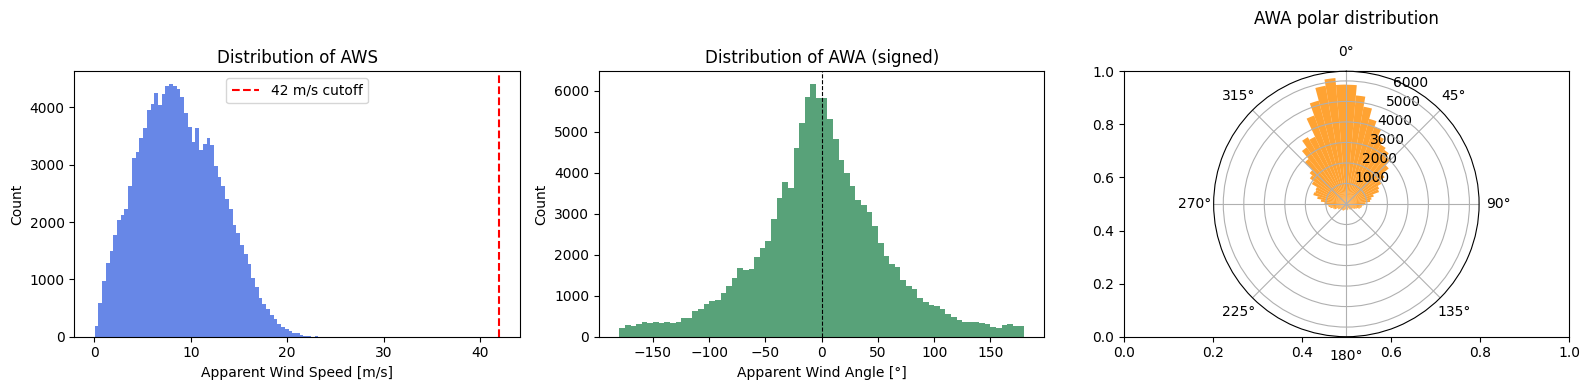

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# AWS distribution
axes[0].hist(df['AWS_ms'].dropna(), bins=60, color='royalblue', edgecolor='none', alpha=0.8)
axes[0].axvline(42, color='red', linestyle='--', label='42 m/s cutoff')
axes[0].set_xlabel('Apparent Wind Speed [m/s]')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of AWS')
axes[0].legend()

# AWA distribution (signed)
axes[1].hist(df['AWA_deg'].dropna(), bins=72, color='seagreen', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('Apparent Wind Angle [°]')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of AWA (signed)')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')

# Polar plot of AWA frequency
ax_polar = fig.add_subplot(133, projection='polar')
awa_rad = np.deg2rad(df['AWA_deg'].dropna())
ax_polar.hist(awa_rad, bins=72, color='darkorange', alpha=0.8)
ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)
ax_polar.set_title('AWA polar distribution', pad=15)

plt.tight_layout()
plt.show()

## 3. Rotor Power Lookup Table

The vessel is equipped with **1 × Norsepower 24v4 Flettner rotor** (24 m height, 4 m diameter). The manufacturer's polar diagram shows **Rotor Propulsion Power [kW]** as a function of **true wind speed [m/s]** and **wind angle [°]**, at STW = 19 kn and efficiency factor EFF = 0.7.

### Digitization approach
We read the concentric power curves from the polar diagram and record approximate power values at key angles for each wind speed. The diagram is symmetric (port = starboard), so we only need angles 0°–180°.

**Key observations from the diagram:**
- Power is **near zero** at 0° (direct headwind) and 180° (direct tailwind)
- Peak power occurs around **60°–120° (abeam)** - this is the optimal zone for Flettner rotors
- At very low wind angles (~0°) with high wind speeds, the rotor can produce **negative thrust** (acts as drag)
- Power scales approximately with the square of wind speed

We then build a **2D interpolation function** (bilinear) using `scipy.interpolate.RegularGridInterpolator`, which allows querying any (AWS, AWA) pair.

> **Simplification note:** The diagram is defined for true wind. We use apparent wind (AWS, AWA) as input - a standard engineering approximation acceptable at the scale of this analysis.

In [11]:
# ---------------------------------------------------------------------------
# Digitized values from the 24v4 polar diagram
# Rows = wind speed [m/s], Columns = wind angle from bow [degrees]
# Power values in [kW] for 1 rotor, STW=19kn, EFF=0.7
# Negative values indicate the rotor produces drag at that condition
# ---------------------------------------------------------------------------

WIND_SPEEDS = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])  # [m/s]
WIND_ANGLES = np.array([0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180])  # [degrees]

# Power table [kW] - shape: (len(WIND_SPEEDS), len(WIND_ANGLES))
POWER_TABLE = np.array([
    #    0°     20°    40°    60°    80°    90°   100°   120°   140°   160°   180°
    [0, 3, 10, 14, 16, 14, 12, 7, 3, 1, 0],  #  4 m/s
    [-2, 6, 22, 38, 44, 42, 38, 22, 9, 3, 0],  #  6 m/s
    [-5, 12, 45, 78, 90, 87, 78, 46, 19, 7, 0],  #  8 m/s
    [-8, 20, 75, 128, 148, 144, 130, 76, 32, 11, 0],  # 10 m/s
    [-12, 30, 110, 186, 215, 210, 188, 110, 46, 16, 0],  # 12 m/s
    [-16, 42, 152, 256, 297, 290, 260, 152, 64, 22, 0],  # 14 m/s
    [-21, 56, 200, 335, 390, 380, 340, 199, 83, 29, 0],  # 16 m/s
    [-27, 72, 254, 425, 496, 484, 433, 254, 106, 37, 0],  # 18 m/s
    [-33, 90, 315, 526, 614, 599, 537, 314, 131, 46, 0],  # 20 m/s
    [-40, 110, 382, 638, 745, 727, 651, 381, 159, 55, 0],  # 22 m/s
    [-48, 132, 456, 762, 890, 868, 778, 455, 190, 66, 0],  # 24 m/s
])

print(f"Power table shape: {POWER_TABLE.shape}  (wind speeds × angles)")
print(
    f"Max rotor power in table: {POWER_TABLE.max():.0f} kW  at wind speed {WIND_SPEEDS[np.unravel_index(POWER_TABLE.argmax(), POWER_TABLE.shape)[0]]} m/s, angle {WIND_ANGLES[np.unravel_index(POWER_TABLE.argmax(), POWER_TABLE.shape)[1]]}°")

Power table shape: (11, 11)  (wind speeds × angles)
Max rotor power in table: 890 kW  at wind speed 24 m/s, angle 80°


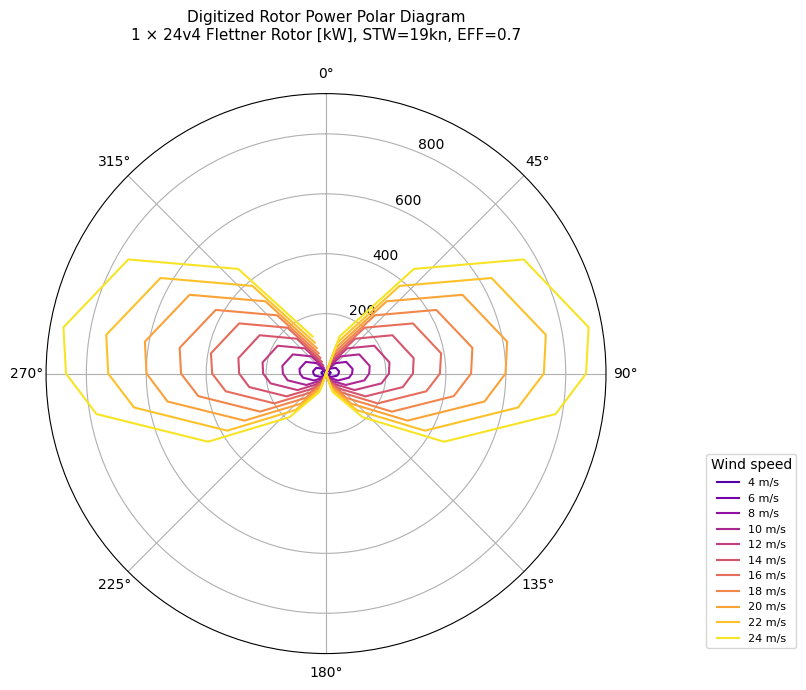

In [12]:
fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

colors = cm.plasma(np.linspace(0.15, 0.95, len(WIND_SPEEDS)))

for i, (ws, color) in enumerate(zip(WIND_SPEEDS, colors)):
    # Mirror the table to full 360° (symmetric: port = starboard)
    angles_full = np.concatenate([WIND_ANGLES, 360 - WIND_ANGLES[-2:0:-1]])
    power_full = np.concatenate([POWER_TABLE[i], POWER_TABLE[i][-2:0:-1]])

    # Clip negatives to zero for plotting (negative = drag, not plotted as thrust)
    power_plot = np.maximum(power_full, 0)

    ax.plot(np.deg2rad(angles_full), power_plot, color=color, linewidth=1.5, label=f'{ws} m/s')

ax.set_title('Digitized Rotor Power Polar Diagram\n1 × 24v4 Flettner Rotor [kW], STW=19kn, EFF=0.7',
             pad=20, fontsize=11)
ax.legend(loc='lower right', bbox_to_anchor=(1.35, 0.0), title='Wind speed', fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
_rotor_interp = RegularGridInterpolator(
    (WIND_SPEEDS, WIND_ANGLES),
    POWER_TABLE,
    method='linear',
    bounds_error=False,
    fill_value=None
)


def rotor_power_kw(aws_ms: float | np.ndarray, awa_abs_deg: float | np.ndarray) -> np.ndarray:
    """
    Estimate Flettner rotor propulsion power [kW] from apparent wind conditions.

    aws_ms      : Apparent Wind Speed [m/s]
    awa_abs_deg : Absolute Apparent Wind Angle [0°, 180°] (symmetric, port = starboard)
    power_kw : Estimated rotor power [kW]. Negative values indicate drag.
    """
    aws_ms = np.asarray(aws_ms, dtype=float)
    awa_abs_deg = np.asarray(awa_abs_deg, dtype=float)

    # Clamp AWS to the table range - above 24 m/s we use the 24 m/s row
    aws_clamped = np.clip(aws_ms, WIND_SPEEDS.min(), WIND_SPEEDS.max())
    # AWA is already [0, 180] - clamp just for safety
    awa_clamped = np.clip(awa_abs_deg, WIND_ANGLES.min(), WIND_ANGLES.max())

    points = np.column_stack([aws_clamped.ravel(), awa_clamped.ravel()])
    return _rotor_interp(points).reshape(aws_ms.shape)


print("Test lookup values:")
print(f"  AWS=10 m/s, AWA=90° (abeam)   → {rotor_power_kw(10, 90):.1f} kW  (should be near peak)")
print(f"  AWS=10 m/s, AWA=0°  (headwind) → {rotor_power_kw(10, 0):.1f} kW  (should be negative/zero)")
print(f"  AWS=10 m/s, AWA=180° (tailwind) → {rotor_power_kw(10, 180):.1f} kW (should be near zero)")
print(f"  AWS=2  m/s, AWA=90°  (light air) → {rotor_power_kw(2, 90):.1f} kW  (below table range, extrapolated)")

Test lookup values:
  AWS=10 m/s, AWA=90° (abeam)   → 144.0 kW  (should be near peak)
  AWS=10 m/s, AWA=0°  (headwind) → -8.0 kW  (should be negative/zero)
  AWS=10 m/s, AWA=180° (tailwind) → 0.0 kW (should be near zero)
  AWS=2  m/s, AWA=90°  (light air) → 14.0 kW  (below table range, extrapolated)


In [14]:
df['Rotor_Power_kW'] = rotor_power_kw(
    df['AWS_ms'].values,
    df['AWA_abs_deg'].values
)

print("Rotor Power distribution [kW]:")
print(df['Rotor_Power_kW'].describe().round(2))
print(f"\nRows with negative power (drag condition): {(df['Rotor_Power_kW'] < 0).sum():,}")

Rotor Power distribution [kW]:
count    125160.00
mean         47.80
std          67.09
min         -30.80
25%           4.93
50%          19.30
75%          65.74
max         621.11
Name: Rotor_Power_kW, dtype: float64

Rows with negative power (drag condition): 11,886


## 4. Rotor Active Flag (`is_rotor_active`)

The Flettner rotors on SC CONNECTOR were installed at the beginning of 2021 and have been mechanically present throughout the dataset. However, the rotors are **operationally deactivated** under certain adverse conditions to protect the vessel and equipment.

Based on consultation with the vessel operator (Mr. Artur / Mr. Patryk), the operational rules are:

| Condition | Rotor state | Reason |
|---|---|---|
| H_s > 6 m | OFF (0) | Maximum significant wave height limit |
| AWS > 42 m/s | OFF (0) | Maximum apparent wind speed limit |
| Rotor power < 0 kW | OFF (0) | Wind angle produces drag, not thrust - no benefit |
| All other conditions | ON (1) | Rotors generate positive propulsive force |

This flag serves two purposes in the ML pipeline:
1. **Input feature** - tells the model whether wind assistance was available at each timestep
2. **Scenario simulation** - we can force `is_rotor_active = 0` across all rows to simulate a baseline (no rotor) vessel and compare predicted SOG / transit time

In [15]:
# Apply boundary conditions - rotors are OFF (0) when any condition is met
hs_exceeded = df['H_s'] > 6.0  # wave height limit
aws_exceeded = df['AWS_ms'] > 42.0  # wind speed limit
negative_thrust = df['Rotor_Power_kW'] < 0.0  # rotor would create drag

df['is_rotor_active'] = 1  # start with all ON
df.loc[hs_exceeded | aws_exceeded | negative_thrust, 'is_rotor_active'] = 0

total = len(df)
on = (df['is_rotor_active'] == 1).sum()
off = (df['is_rotor_active'] == 0).sum()

print(f"Rotor ON  (1): {on:>8,} rows  ({on / total * 100:.1f}%)")
print(f"Rotor OFF (0): {off:>8,} rows  ({off / total * 100:.1f}%)")
print(f"\nBreakdown of OFF reasons (rows can satisfy multiple):")
print(f"  H_s > 6 m:             {hs_exceeded.sum():>7,} rows  ({hs_exceeded.sum() / total * 100:.1f}%)")
print(f"  AWS > 42 m/s:          {aws_exceeded.sum():>7,} rows  ({aws_exceeded.sum() / total * 100:.1f}%)")
print(f"  Negative rotor thrust: {negative_thrust.sum():>7,} rows  ({negative_thrust.sum() / total * 100:.1f}%)")

Rotor ON  (1):  113,255 rows  (90.5%)
Rotor OFF (0):   11,905 rows  (9.5%)

Breakdown of OFF reasons (rows can satisfy multiple):
  H_s > 6 m:                  19 rows  (0.0%)
  AWS > 42 m/s:                0 rows  (0.0%)
  Negative rotor thrust:  11,886 rows  (9.5%)


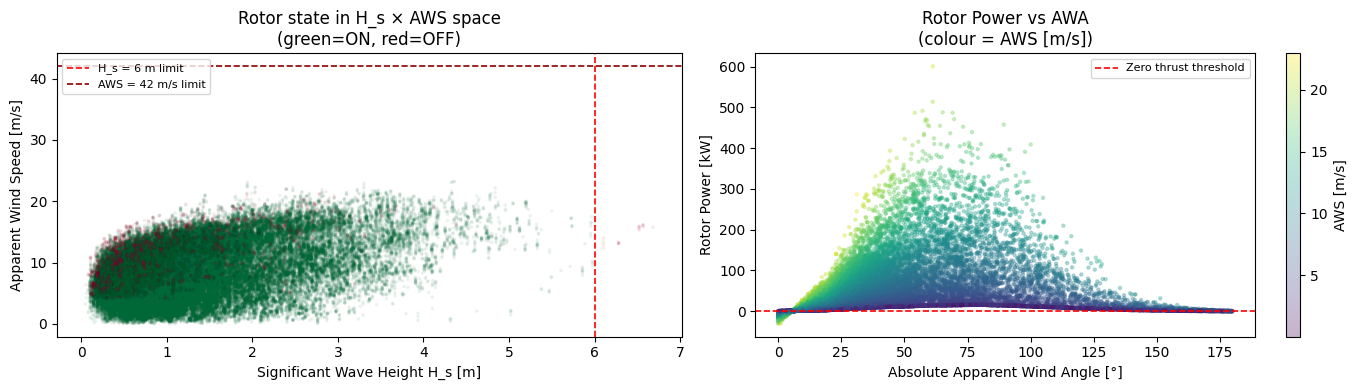

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# H_s vs is_rotor_active
axes[0].scatter(
    df['H_s'], df['AWS_ms'],
    c=df['is_rotor_active'], cmap='RdYlGn', alpha=0.05, s=3, vmin=0, vmax=1
)
axes[0].axvline(6.0, color='red', linestyle='--', linewidth=1.2, label='H_s = 6 m limit')
axes[0].axhline(42.0, color='darkred', linestyle='--', linewidth=1.2, label='AWS = 42 m/s limit')
axes[0].set_xlabel('Significant Wave Height H_s [m]')
axes[0].set_ylabel('Apparent Wind Speed [m/s]')
axes[0].set_title('Rotor state in H_s × AWS space\n(green=ON, red=OFF)')
axes[0].legend(fontsize=8)

# Rotor power vs AWA
sample = df.sample(min(20000, len(df)), random_state=42)
sc = axes[1].scatter(
    sample['AWA_abs_deg'], sample['Rotor_Power_kW'],
    c=sample['AWS_ms'], cmap='viridis', alpha=0.3, s=5
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2, label='Zero thrust threshold')
axes[1].set_xlabel('Absolute Apparent Wind Angle [°]')
axes[1].set_ylabel('Rotor Power [kW]')
axes[1].set_title('Rotor Power vs AWA\n(colour = AWS [m/s])')
plt.colorbar(sc, ax=axes[1], label='AWS [m/s]')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Final Dataset Overview and Export

We drop the internal helper columns (`_ship_vx`, `_ship_vy`) used for intermediate calculations and save the enriched dataset.

In [17]:
df = df.drop(columns=['_ship_vx', '_ship_vy'])

print("Final columns:")
for col in df.columns:
    print(f"  {col:<30} {df[col].dtype}")

Final columns:
  Time                           datetime64[ns]
  Lat                            float64
  Lon                            float64
  Speed_kn                       float64
  Calc_Speed_kn                  float64
  Course_deg                     float64
  Dist_since_last_nm             float64
  Total_dist_nm                  float64
  Voyage_ID                      int64
  u10                            float64
  v10                            float64
  H_s                            float64
  mwd                            float64
  mwp                            float64
  fg10                           float64
  uo                             float64
  vo                             float64
  True_Wind_Speed_ms             float64
  STW_ms                         float64
  STW_kn                         float64
  STH_deg                        float64
  AWS_ms                         float64
  AWA_deg                        float64
  AWA_abs_deg                    floa

In [18]:
engineered = ['STW_ms', 'STW_kn', 'STH_deg', 'AWS_ms', 'AWA_deg', 'AWA_abs_deg', 'Rotor_Power_kW', 'is_rotor_active']

print("Summary of engineered features:")
print(df[engineered].describe().round(3))

Summary of engineered features:
           STW_ms      STW_kn     STH_deg      AWS_ms     AWA_deg  \
count  125160.000  125160.000  125160.000  125160.000  125160.000   
mean        5.934      11.534     173.206       8.817      -1.113   
std         1.101       2.139     111.125       4.133      58.689   
min         2.109       4.100       0.000       0.032    -179.963   
25%         5.239      10.183      92.660       5.698     -32.789   
50%         6.006      11.675     182.420       8.547      -1.855   
75%         6.591      12.811     231.223      11.827      31.880   
max        10.263      19.949     359.999      23.228     179.998   

       AWA_abs_deg  Rotor_Power_kW  is_rotor_active  
count   125160.000      125160.000       125160.000  
mean        43.746          47.802            0.905  
std         39.140          67.085            0.293  
min          0.000         -30.803            0.000  
25%         13.804           4.930            1.000  
50%         32.353    

In [19]:
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}")
print(f"Shape: {df.shape}")

Saved to MasterSet_features.csv
Shape: (125160, 26)
